In [1]:
import itertools
import numpy as np
import pandas as pd
from dtw import dtw
import matplotlib.pyplot as plt
import math

from ipywidgets import interact, widgets, fixed

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
def make_sections(dfs, section_names, params, skips=None):
    """
    Extract multivariate arrays from Excel sheets.

    Returns
    -------
    sections : dict
        {section_name: array of shape (n_points, n_params)}
    """
    if skips is None:
        skips = {}

    sections = {}

    for name in section_names:
        skip = skips.get(name, 0)

        arr = (
            dfs[name][params]
            .iloc[skip:]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy(dtype=float)
        )

        sections[name] = arr

    return sections

In [3]:
def make_weight_vector(params, weights=None):
    """
    Convert either a dict or a list/array of weights to a numpy vector.
    """
    if weights is None:
        return np.ones(len(params), dtype=float)

    if isinstance(weights, dict):
        return np.array([weights.get(p, 1.0) for p in params], dtype=float)

    weights = np.asarray(weights, dtype=float)

    if len(weights) != len(params):
        raise ValueError("weights must have the same length as params.")

    return weights


In [4]:
def make_circular_mask(params, circular_params=("Dgeo",)):
    """
    Mark circular variables, e.g. declination in degrees.
    """
    circular_params = set(circular_params)
    return np.array([p in circular_params for p in params], dtype=bool)

In [5]:
def compute_global_scales(
    sections,
    params=None,
    method="mad",
    scale_overrides=None,
    min_scale=1e-12,
):
    """
    Estimate one scale per parameter across all sections.

    method="mad" is robust.
    method="std" uses standard deviation.

    scale_overrides can be used for known measurement precision, e.g.
    {"Dgeo": 15.0, "Igeo": 10.0}
    """
    all_values = np.vstack(list(sections.values()))

    if method == "mad":
        center = np.nanmedian(all_values, axis=0)
        mad = np.nanmedian(np.abs(all_values - center), axis=0)
        scales = 1.4826 * mad
    elif method == "std":
        scales = np.nanstd(all_values, axis=0)
    else:
        raise ValueError("method must be 'mad' or 'std'.")

    scales = np.asarray(scales, dtype=float)
    scales[~np.isfinite(scales)] = 1.0
    scales[scales < min_scale] = 1.0

    if scale_overrides is not None:
        if params is None:
            raise ValueError("params must be provided when using scale_overrides.")

        for param_name, scale_value in scale_overrides.items():
            if param_name not in params:
                raise ValueError(f"{param_name!r} is not in params.")
            scales[params.index(param_name)] = float(scale_value)

    return scales

In [6]:
def circular_difference_degrees(a, b):
    """
    Smallest signed angular difference a - b for degrees.
    Result is in [-180, 180].
    """
    return (a - b + 180.0) % 360.0 - 180.0

In [7]:
def weighted_nan_dist(
    a,
    b,
    weights=None,
    scales=None,
    circular=None,
    metric="l1",
    missing_penalty=0.0,
    empty_penalty=1e6,
    nan_penalty=1.0,
):
    """
    Weighted multivariate local distance for DTW.

    This version follows the older working logic:
    - normal finite values are compared after scaling;
    - circular variables, e.g. Dgeo, are handled correctly;
    - missing values get a small finite penalty;
    - there is no huge empty-row penalty.

    missing_penalty and empty_penalty are kept only for compatibility
    with the rest of the current code.
    """
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    n = len(a)

    if weights is None:
        weights = np.ones(n, dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)

    if scales is None:
        scales = np.ones(n, dtype=float)
    else:
        scales = np.asarray(scales, dtype=float)

    if circular is None:
        circular = np.zeros(n, dtype=bool)
    else:
        circular = np.asarray(circular, dtype=bool)

    if not (len(b) == len(weights) == len(scales) == len(circular) == n):
        raise ValueError("a, b, weights, scales, and circular must have compatible lengths.")

    total = 0.0
    total_weight = 0.0

    for ak, bk, wk, sk, is_circular in zip(a, b, weights, scales, circular):
        if not np.isfinite(wk) or wk <= 0:
            continue

        if not np.isfinite(sk) or sk <= 0:
            sk = 1.0

        if not np.isfinite(ak) or not np.isfinite(bk):
            if metric == "l1":
                total += wk * nan_penalty
            elif metric == "l2":
                total += wk * nan_penalty**2
            else:
                raise ValueError("metric must be 'l1' or 'l2'.")
        else:
            if is_circular:
                diff = circular_difference_degrees(ak, bk)
            else:
                diff = ak - bk

            z = abs(diff) / sk

            if metric == "l1":
                total += wk * z
            elif metric == "l2":
                total += wk * z * z
            else:
                raise ValueError("metric must be 'l1' or 'l2'.")

        total_weight += wk

    if total_weight == 0:
        return float(nan_penalty)

    if metric == "l1":
        return float(total / total_weight)

    if metric == "l2":
        return float(np.sqrt(total / total_weight))

In [8]:
def prepare_anchors(anchors, n_x, n_y, add_endpoints=True):
    """
    Validate anchors for x and y.

    Anchors must be pairs of post-skip indices:
        [(x_index, y_index), ...]

    They must be monotonic in both x and y.
    """
    if anchors is None:
        anchors = []

    anchors = [(int(i), int(j)) for i, j in anchors]

    if add_endpoints:
        if (0, 0) not in anchors:
            anchors.append((0, 0))
        if (n_x - 1, n_y - 1) not in anchors:
            anchors.append((n_x - 1, n_y - 1))

    anchors = sorted(set(anchors), key=lambda t: (t[0], t[1]))

    for i, j in anchors:
        if i < 0 or i >= n_x or j < 0 or j >= n_y:
            raise ValueError(
                f"Anchor {(i, j)} is outside array sizes {(n_x, n_y)}."
            )

    for (i0, j0), (i1, j1) in zip(anchors[:-1], anchors[1:]):
        if i1 <= i0 or j1 <= j0:
            raise ValueError(
                "Anchors must be strictly increasing in both sections. "
                f"Problem: {(i0, j0)} -> {(i1, j1)}"
            )

    return anchors

In [9]:
def get_pair_anchors(name_x, name_y, n_x, n_y, anchors_by_pair=None):
    """
    Fetch anchors for a pair of sections.

    anchors_by_pair example:
    {
        ("C", "B"): [(0, 0), (4, 3), (15, 13)]
    }

    If a reversed key exists, anchors are automatically swapped.
    If no anchors are provided, only endpoints are used.
    """
    if anchors_by_pair is None:
        anchors = None
    elif (name_x, name_y) in anchors_by_pair:
        anchors = anchors_by_pair[(name_x, name_y)]
    elif (name_y, name_x) in anchors_by_pair:
        anchors = [(j, i) for i, j in anchors_by_pair[(name_y, name_x)]]
    else:
        anchors = None

    return prepare_anchors(anchors, n_x=n_x, n_y=n_y, add_endpoints=True)

In [10]:
def anchored_dtw_multi(
    x,
    y,
    anchors=None,
    weights=None,
    scales=None,
    circular=None,
    metric="l1",
    missing_penalty=0.0,
    empty_penalty=1e6,
    normalize_distance=True,
    **dtw_kwargs,
):
    """
    Anchored multivariate DTW between two sections.

    Returns
    -------
    result : dict
        index_x : indices in x along final warping path
        index_y : indices in y along final warping path
        distance : recomputed final path distance, without duplicated anchor costs
        normalized_distance : distance / path_length
        path_length : number of matched pairs in final path
        anchors : validated anchor list
        dtw_objective_distance : raw sum of DTW segment objective distances
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    if y.ndim == 1:
        y = y.reshape(-1, 1)

    if x.shape[1] != y.shape[1]:
        raise ValueError("x and y must have the same number of parameters.")

    anchors = prepare_anchors(
        anchors,
        n_x=len(x),
        n_y=len(y),
        add_endpoints=True,
    )

    def dist_method(a, b):
        return weighted_nan_dist(
            a,
            b,
            weights=weights,
            scales=scales,
            circular=circular,
            metric=metric,
            missing_penalty=missing_penalty,
            empty_penalty=empty_penalty,
        )

    full_index_x = []
    full_index_y = []
    dtw_objective_distance = 0.0

    for (i_start, j_start), (i_end, j_end) in zip(anchors[:-1], anchors[1:]):
        x_seg = x[i_start : i_end + 1]
        y_seg = y[j_start : j_end + 1]

        alignment = dtw(
            x_seg,
            y_seg,
            dist_method=dist_method,
            keep_internals=True,
            **dtw_kwargs,
        )

        idx_x = np.asarray(alignment.index1, dtype=int) + i_start
        idx_y = np.asarray(alignment.index2, dtype=int) + j_start

        # Avoid duplicate anchor pair at segment boundary.
        if len(full_index_x) > 0:
            idx_x = idx_x[1:]
            idx_y = idx_y[1:]

        full_index_x.extend(idx_x)
        full_index_y.extend(idx_y)

        # Keep this only as diagnostic information.
        dtw_objective_distance += float(alignment.distance)

    full_index_x = np.asarray(full_index_x, dtype=int)
    full_index_y = np.asarray(full_index_y, dtype=int)

    path_length = len(full_index_x)

    # Recompute the actual path distance after duplicate anchor removal.
    path_costs = [
        dist_method(x[i], y[j])
        for i, j in zip(full_index_x, full_index_y)
    ]

    distance = float(np.sum(path_costs))

    if normalize_distance:
        normalized_distance = distance / max(path_length, 1)
    else:
        normalized_distance = distance

    return {
        "index_x": full_index_x,
        "index_y": full_index_y,
        "distance": distance,
        "normalized_distance": normalized_distance,
        "path_length": path_length,
        "anchors": anchors,
        "dtw_objective_distance": dtw_objective_distance,
    }

In [11]:
def pairwise_dtw_matrix(
    sections,
    params,
    weights=None,
    scales=None,
    anchors_by_pair=None,
    circular_params=("Dgeo",),
    metric="l1",
    missing_penalty=0.0,
    empty_penalty=1e6,
    **dtw_kwargs,
):
    """
    Compute all-vs-all multivariate DTW distances.

    Returns
    -------
    distance_matrix : pandas.DataFrame
        Symmetric matrix of normalized DTW distances.

    alignments : dict
        {(name_x, name_y): alignment_result}
    """
    names = list(sections.keys())

    weights = make_weight_vector(params, weights)

    if scales is None:
        scales = compute_global_scales(sections, params=params, method="mad")

    circular = make_circular_mask(params, circular_params=circular_params)

    distance_matrix = pd.DataFrame(
        np.zeros((len(names), len(names))),
        index=names,
        columns=names,
        dtype=float,
    )

    alignments = {}

    for name_x, name_y in itertools.combinations(names, 2):
        x = sections[name_x]
        y = sections[name_y]

        anchors = get_pair_anchors(
            name_x,
            name_y,
            n_x=len(x),
            n_y=len(y),
            anchors_by_pair=anchors_by_pair,
        )

        result = anchored_dtw_multi(
            x,
            y,
            anchors=anchors,
            weights=weights,
            scales=scales,
            circular=circular,
            metric=metric,
            missing_penalty=missing_penalty,
            empty_penalty=empty_penalty,
            **dtw_kwargs,
        )

        d = result["normalized_distance"]

        distance_matrix.loc[name_x, name_y] = d
        distance_matrix.loc[name_y, name_x] = d

        alignments[(name_x, name_y)] = result

    return distance_matrix, alignments

In [12]:
def choose_dtw_medoid(distance_matrix):
    """
    Choose the section with the smallest mean distance to all other sections.
    Does not modify the original matrix.
    """
    dm = distance_matrix.copy()

    # Safer than np.fill_diagonal(dm.values, np.nan)
    mask = np.eye(len(dm), dtype=bool)
    dm = dm.mask(mask)

    mean_distance = dm.mean(axis=1, skipna=True)
    medoid_name = mean_distance.idxmin()

    return medoid_name, mean_distance

In [13]:
def align_all_to_reference(
    sections,
    reference_name,
    params,
    weights=None,
    scales=None,
    anchors_by_pair=None,
    circular_params=("Dgeo",),
    metric="l1",
    missing_penalty=0.0,
    empty_penalty=1e6,
    **dtw_kwargs,
):
    """
    Align every section to one reference section.

    Output alignment for each non-reference section has:
    - index_x = indices in reference
    - index_y = indices in the aligned section
    """
    if reference_name not in sections:
        raise ValueError(f"{reference_name!r} is not in sections.")

    weights = make_weight_vector(params, weights)

    if scales is None:
        scales = compute_global_scales(sections, params=params, method="mad")

    circular = make_circular_mask(params, circular_params=circular_params)

    ref = sections[reference_name]
    alignments_to_ref = {}

    for name, arr in sections.items():
        if name == reference_name:
            continue

        anchors = get_pair_anchors(
            reference_name,
            name,
            n_x=len(ref),
            n_y=len(arr),
            anchors_by_pair=anchors_by_pair,
        )

        result = anchored_dtw_multi(
            ref,
            arr,
            anchors=anchors,
            weights=weights,
            scales=scales,
            circular=circular,
            metric=metric,
            missing_penalty=missing_penalty,
            empty_penalty=empty_penalty,
            **dtw_kwargs,
        )

        alignments_to_ref[name] = result

    return alignments_to_ref

In [14]:
def evaluate_weight_sets(
    sections,
    params,
    weight_sets,
    scales,
    anchors_by_pair=None,
    circular_params=("Dgeo",),
    metric="l1",
    step_pattern="symmetric2",
    **dtw_kwargs,
):
    """
    Evaluate DTW distance matrices and medoids under several parameter-weight sets.

    Parameters
    ----------
    sections : dict
        Section arrays, e.g. {"A": arr_A, "B": arr_B, ...}

    params : list
        Parameter names in the same order as section array columns.

    weight_sets : dict
        Dictionary of named weight dictionaries.
        Example:
        {
            "balanced": {"Dgeo": 0.25, "Igeo": 1.0, "ARMmax": 0.5},
            "directions_stronger": {"Dgeo": 0.5, "Igeo": 1.5, "ARMmax": 0.25},
        }

    scales : array-like
        Scale vector in the same order as params.

    Returns
    -------
    summary : pandas.DataFrame
        One row per weight set.

    mean_distances_table : pandas.DataFrame
        Rows = sections, columns = weight-set names.
        Values = mean DTW distance to all other sections.

    distance_matrices : dict
        {weight_set_name: distance_matrix}

    pair_alignments_by_weight : dict
        {weight_set_name: pair_alignments}
    """
    results = []
    mean_distances_by_weight = {}
    distance_matrices = {}
    pair_alignments_by_weight = {}

    for weight_name, weights in weight_sets.items():
        dm, pair_alignments = pairwise_dtw_matrix(
            sections=sections,
            params=params,
            weights=weights,
            scales=scales,
            anchors_by_pair=anchors_by_pair,
            circular_params=circular_params,
            metric=metric,
            step_pattern=step_pattern,
            **dtw_kwargs,
        )

        medoid_name, mean_distances = choose_dtw_medoid(dm)

        distance_matrices[weight_name] = dm
        pair_alignments_by_weight[weight_name] = pair_alignments
        mean_distances_by_weight[weight_name] = mean_distances

        sorted_means = mean_distances.sort_values()

        best = sorted_means.iloc[0]
        second = sorted_means.iloc[1]
        margin = second - best
        relative_margin = margin / best if best != 0 else np.nan

        results.append(
            {
                "weight_set": weight_name,
                "medoid": medoid_name,
                "best_mean_distance": best,
                "second_best_section": sorted_means.index[1],
                "second_best_mean_distance": second,
                "absolute_margin": margin,
                "relative_margin": relative_margin,
            }
        )

    summary = pd.DataFrame(results)

    mean_distances_table = pd.DataFrame(mean_distances_by_weight)

    return summary, mean_distances_table, distance_matrices, pair_alignments_by_weight

In [15]:
def test_pair_with_anchors(
    sections,
    params,
    section_x,
    section_y,
    anchors,
    weights,
    scales,
    circular_params=("Dgeo",),
    metric="l1",
    step_pattern="symmetric2",
):
    """
    Compare one pair with and without anchors.
    """
    weight_vec = make_weight_vector(params, weights)
    circular = make_circular_mask(params, circular_params=circular_params)

    no_anchor = anchored_dtw_multi(
        sections[section_x],
        sections[section_y],
        anchors=None,
        weights=weight_vec,
        scales=scales,
        circular=circular,
        metric=metric,
        step_pattern=step_pattern,
    )

    with_anchor = anchored_dtw_multi(
        sections[section_x],
        sections[section_y],
        anchors=anchors,
        weights=weight_vec,
        scales=scales,
        circular=circular,
        metric=metric,
        step_pattern=step_pattern,
    )

    print(f"{section_x} vs {section_y}")
    print("No anchors distance:  ", no_anchor["normalized_distance"])
    print("With anchors distance:", with_anchor["normalized_distance"])
    print("No anchors path length:  ", no_anchor["path_length"])
    print("With anchors path length:", with_anchor["path_length"])

    print("\nAnchor check:")
    for ax, ay in anchors:
        present = np.any(
            (with_anchor["index_x"] == ax)
            & (with_anchor["index_y"] == ay)
        )
        print((ax, ay), present)

    return no_anchor, with_anchor

In [16]:
def dynamic_draw(values, x_pos):

    values = np.asarray(values, dtype=float)

    point_y = values[x_pos]

    fig, ax = plt.subplots()
    ax.plot(values)

    if not np.isnan(point_y):
        ax.scatter(x_pos, point_y, label=f'{x_pos}')
        ax.legend(loc='upper right')
    else:
        ax.legend('N',loc='upper right')
        
    plt.show()

In [46]:
def dynamic_draw_sections(dfs, section_names, param_name, x_pos, skips=None, ncols=3):

    if skips is None:
        skips = {}

    idx = x_pos

    n_sections = len(section_names)
    nrows = math.ceil(n_sections / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.5 * nrows),
        squeeze=False
    )

    axes = axes.ravel()

    for ax, section_name in zip(axes, section_names):

        skip = skips.get(section_name, 0)

        values = (
            dfs[section_name][param_name]
            .iloc[skip:]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy(dtype=float)
        )

        x = np.arange(len(values))

        ax.plot(x, values)
        ax.set_title(f"{section_name}: {param_name}")
        ax.set_xlabel("Index")
        ax.set_ylabel(param_name)

        if idx < len(values):

            point_y = values[idx]

            if not np.isnan(point_y):
                ax.scatter(
                    x_pos,
                    point_y,
                    label=f"{section_name}:{x_pos}",
                    zorder=5
                )
                ax.legend(loc="upper right")

            else:
                ax.plot([], [], ' ', label=f"{section_name}:N")
                ax.legend(loc="upper right")

        else:
            ax.plot([], [], ' ', label=f"{section_name}:N")
            ax.legend(loc="upper right")

    for ax in axes[n_sections:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [79]:
def get_pair_alignment(pair_alignments, ref_name, other_name):
    """
    Return DTW indices as:
        ref_idx   = indices of ref_name
        other_idx = indices of other_name

    Works even if the stored pair is reversed.
    """

    if (ref_name, other_name) in pair_alignments:
        res = pair_alignments[(ref_name, other_name)]
        ref_idx = res["index_x"]
        other_idx = res["index_y"]

    elif (other_name, ref_name) in pair_alignments:
        res = pair_alignments[(other_name, ref_name)]
        ref_idx = res["index_y"]
        other_idx = res["index_x"]

    else:
        raise KeyError(f"No alignment found for {ref_name}-{other_name}")

    return ref_idx, other_idx, res

In [18]:
def parse_data(df, row_name,header_length = 1):
    data = []

    for i, row in df.iterrows():
        if i+1 > header_length:
            data.append([i,row[row_name]])

    return np.asarray(data)

In [83]:
def get_pair_alignment(pair_alignments, ref_name, other_name):
    """
    Return DTW indices in the direction:
        ref_idx   = indices of ref_name
        other_idx = indices of other_name

    Works even if the stored pair is reversed.
    """

    if (ref_name, other_name) in pair_alignments:
        res = pair_alignments[(ref_name, other_name)]
        ref_idx = np.asarray(res["index_x"], dtype=int)
        other_idx = np.asarray(res["index_y"], dtype=int)

    elif (other_name, ref_name) in pair_alignments:
        res = pair_alignments[(other_name, ref_name)]
        ref_idx = np.asarray(res["index_y"], dtype=int)
        other_idx = np.asarray(res["index_x"], dtype=int)

    else:
        raise KeyError(f"No alignment found for {ref_name}-{other_name}")

    return ref_idx, other_idx, res

In [84]:
def collapse_to_reference_grid(ref_idx, other_idx, other_values, n_ref, agg="mean"):
    """
    Collapse one DTW alignment onto the original reference index grid.

    For example, if several points from section B match one medoid point,
    they are aggregated into one value.
    """

    other_values = np.asarray(other_values, dtype=float)

    if other_values.ndim == 1:
        other_values = other_values[:, None]

    aligned = np.full((n_ref, other_values.shape[1]), np.nan)

    for i in range(n_ref):
        mask = ref_idx == i

        if not np.any(mask):
            continue

        vals = other_values[other_idx[mask]]

        if agg == "mean":
            aligned[i] = np.nanmean(vals, axis=0)
        elif agg == "median":
            aligned[i] = np.nanmedian(vals, axis=0)
        elif agg == "first":
            aligned[i] = vals[0]
        elif agg == "last":
            aligned[i] = vals[-1]
        else:
            raise ValueError("agg must be one of: 'mean', 'median', 'first', 'last'")

    return aligned

In [85]:
def plot_all_sections_to_medoid(
    sections,
    params,
    pair_alignments,
    medoid,
    section_names=None,
    param_names=None,
    skips=None,
    agg="mean",
    ncols=3,
    figsize_per_panel=(5, 3),
    linewidth=1.5,
    alpha=0.9,
    show_points=False,
):
    """
    Plot all sections aligned to the medoid reference grid.

    X-axis = original medoid point index.
    Y-axis = parameter value.

    Each non-medoid section is warped to the medoid and collapsed onto
    the medoid index grid.
    """

    if section_names is None:
        section_names = list(sections.keys())

    if param_names is None:
        param_names = params

    if skips is None:
        skips = {}

    n_ref = len(sections[medoid])
    medoid_skip = skips.get(medoid, 0)

    x_ref = np.arange(n_ref) + medoid_skip

    aligned_to_medoid = {
        medoid: np.asarray(sections[medoid], dtype=float)
    }

    for other in section_names:
        if other == medoid:
            continue

        ref_idx, other_idx, res = get_pair_alignment(
            pair_alignments=pair_alignments,
            ref_name=medoid,
            other_name=other,
        )

        aligned_to_medoid[other] = collapse_to_reference_grid(
            ref_idx=ref_idx,
            other_idx=other_idx,
            other_values=sections[other],
            n_ref=n_ref,
            agg=agg,
        )

    n_params = len(param_names)
    nrows = math.ceil(n_params / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        sharex=True,
    )

    axes = np.asarray(axes).ravel()

    for ax, param_name in zip(axes, param_names):
        param_id = params.index(param_name)

        for name in section_names:
            y = aligned_to_medoid[name][:, param_id]

            if name == medoid:
                ax.plot(
                    x_ref,
                    y,
                    label=f"{name} medoid",
                    linewidth=linewidth + 0.8,
                    alpha=1.0,
                )
            else:
                ax.plot(
                    x_ref,
                    y,
                    label=name,
                    linewidth=linewidth,
                    alpha=alpha,
                )

            if show_points:
                ax.scatter(x_ref, y, s=12, alpha=alpha)

        ax.set_title(param_name)
        ax.set_xlabel(f"{medoid} index")
        ax.grid(True, alpha=0.3)

    for ax in axes[n_params:]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=min(len(section_names), 6),
        bbox_to_anchor=(0.5, 1.02),
    )

    fig.tight_layout()
    plt.show()

    return aligned_to_medoid

In [94]:
def plot_all_warped_param(
    aligned_to_medoid,
    params,
    param_name="Dgeo",
    section_names=None,
    figsize=(12, 5),
    linewidth=1.5,
    alpha=0.8,
):
    param_id = list(params).index(param_name)

    if section_names is None:
        section_names = list(aligned_to_medoid.keys())

    plt.figure(figsize=figsize)

    for name in section_names:
        y = aligned_to_medoid[name][:, param_id]
        warp_axis = np.arange(len(y))

        plt.plot(
            warp_axis,
            y,
            label=name,
            linewidth=linewidth,
            alpha=alpha,
        )

    plt.xlabel("DTW warped coordinate")
    plt.ylabel(param_name)
    plt.title(f"All samples warped: {param_name}")
    plt.legend(loc="upper right")
    plt.grid(alpha=0.25)
    plt.show()

In [19]:
def compare_anchor_effect(matrices_no_anchor, matrices_anchor, weight_set="balanced"):
    return matrices_anchor[weight_set] - matrices_no_anchor[weight_set]

In [20]:
xl_file = pd.ExcelFile('I_full data.xlsx')

dfs = {sheet_name: xl_file.parse(sheet_name) 
          for sheet_name in xl_file.sheet_names}

In [21]:
depth_min = 0
depth_max = 120

In [22]:
dfs['B'].columns

Index(['thickness, mm', 'Piece', 'sample №', 'thick, mm', 'weight, g',
       'Vol, cm3', 'depth, mm', 'Dgeo', 'Igeo', 'MADgeo', 'NRMmax (Am2/kg)',
       'ARMmax (Am2/kg)'],
      dtype='str')

In [23]:
section_names = [
    "A",
    "B",
    "C",
    "D",
    #"E",
    #"F",
]

params = [
    "Dgeo",
    "Igeo",
    #"NRMmax (Am2/kg)",
    "ARMmax (Am2/kg)",
]

skips = {
    "A": 1,
    "B": 1,
    "C": 1,
    "D": 1,
    #"E": 1,
    #"F": 1,
}

In [99]:
param_anc = 'Igeo'

max_len = max(
    len(dfs[name].iloc[skips.get(name, 0):])
    for name in section_names
)

interact(
    dynamic_draw_sections,
    dfs=fixed(dfs),
    section_names=fixed(section_names),
    param_name=fixed(param_anc),
    skips=fixed(skips),
    x_pos=widgets.IntSlider(
        min=0,
        max=max_len - 1,
        step=1,
        value=0,
        description="Index"
    ),
    ncols=fixed(4)
)

param_anc = 'Dgeo'
max_len = max(
    len(dfs[name].iloc[skips.get(name, 0):])
    for name in section_names
)

interact(
    dynamic_draw_sections,
    dfs=fixed(dfs),
    section_names=fixed(section_names),
    param_name=fixed(param_anc),
    skips=fixed(skips),
    x_pos=widgets.IntSlider(
        min=0,
        max=max_len - 1,
        step=1,
        value=0,
        description="Index"
    ),
    ncols=fixed(4)
)

param_anc = 'ARMmax (Am2/kg)'
max_len = max(
    len(dfs[name].iloc[skips.get(name, 0):])
    for name in section_names
)

interact(
    dynamic_draw_sections,
    dfs=fixed(dfs),
    section_names=fixed(section_names),
    param_name=fixed(param_anc),
    skips=fixed(skips),
    x_pos=widgets.IntSlider(
        min=0,
        max=max_len - 1,
        step=1,
        value=0,
        description="Index"
    ),
    ncols=fixed(4)
)

interactive(children=(IntSlider(value=0, description='Index', max=36), Output()), _dom_classes=('widget-intera…

interactive(children=(IntSlider(value=0, description='Index', max=36), Output()), _dom_classes=('widget-intera…

interactive(children=(IntSlider(value=0, description='Index', max=36), Output()), _dom_classes=('widget-intera…

<function __main__.dynamic_draw_sections(dfs, section_names, param_name, x_pos, skips=None, ncols=3)>

In [64]:
anchors_CD = [
    (0, 0),
    (4, 4),
    (14, 16),
    (29, 31),
]

In [55]:
anchors_BD = [
    (0, 0),
    (3, 4),
    (13, 16),
    (29, 31),
]

In [52]:
anchors_BC = [
    (0, 0),
    (3, 4),
    (13, 14),
    (29, 29),
]

In [50]:
anchors_AD = [
    (0,0),
    (4,4),
    (12,16),
    (30,31),
]

In [143]:
anchors_AC = [
    (0,0),
    (4,4),
    (12,14),
    (30,29),
]

In [48]:
anchors_AB =[
    (0, 0),
    (4,3),
    (12,13),
    (30,29),    
]

In [65]:
anchors_by_pair = {
    ("A","B"): anchors_AB,
    ("A", "C"): anchors_AC,
    ("A", "D"):  anchors_AD,
    ("B", "C"): anchors_BC,
    ("B", "D"): anchors_BD,
    ("C", "D"): anchors_CD,    
}

In [66]:
sections = make_sections(
    dfs=dfs,
    section_names=section_names,
    params=params,
    skips=skips,
)

In [67]:
for name, arr in sections.items():
    print(name, arr.shape, "NaNs:", np.isnan(arr).sum())

A (37, 3) NaNs: 22
B (37, 3) NaNs: 9
C (36, 3) NaNs: 9
D (36, 3) NaNs: 10


In [129]:
weights = {
    "Dgeo": 1.0,
    "Igeo": 1.0,
    #"NRMmax (Am2/kg)": 0.25,
    "ARMmax (Am2/kg)": 1.0,
}

In [130]:
scales = compute_global_scales(
    sections,
    params=params,
    method="mad",
    scale_overrides={
        "Dgeo": 20.0,
        "Igeo": 10.0,
    },
)

pd.Series(scales, index=params)

Dgeo               2.000000e+01
Igeo               1.000000e+01
ARMmax (Am2/kg)    1.800257e-07
dtype: float64

In [131]:
distance_matrix_anchor, pair_alignments_anchor = pairwise_dtw_matrix(
    sections=sections,
    params=params,
    weights=weights,
    scales=scales,
    anchors_by_pair=anchors_by_pair,
    circular_params=("Dgeo",),
    metric="l1",
    missing_penalty=0.0,
    step_pattern="symmetric2",
)


In [132]:
distance_matrix_anchor

,A,B,C,D
A,0.000000,1.236277,1.380251,1.334721
B,1.236277,0.000000,1.355878,1.383308
C,1.380251,1.355878,0.000000,1.135539
D,1.334721,1.383308,1.135539,0.000000


In [133]:
medoid_name_anchor, mean_distances_anchor = choose_dtw_medoid(distance_matrix_anchor)

print("Anchored medoid:", medoid_name_anchor)
print(mean_distances_anchor.sort_values())

Anchored medoid: D
D    1.284523
C    1.290556
A    1.317083
B    1.325154
dtype: float64


In [134]:
distance_matrix_no_anchor, pair_alignments_no_anchor = pairwise_dtw_matrix(
    sections=sections,
    params=params,
    weights=weights,
    scales=scales,
    anchors_by_pair=None,
    circular_params=("Dgeo",),
    metric="l1",
    missing_penalty=0.0,
    step_pattern="symmetric2",
)

anchor_effect = distance_matrix_anchor - distance_matrix_no_anchor

print("No anchors:")
display(distance_matrix_no_anchor)

print("With anchors:")
display(distance_matrix_anchor)

print("Anchor effect: anchored - non-anchored")
display(anchor_effect)

No anchors:


,A,B,C,D
A,0.000000,1.096606,1.255386,1.192450
B,1.096606,0.000000,1.290382,1.300543
C,1.255386,1.290382,0.000000,1.084789
D,1.192450,1.300543,1.084789,0.000000


With anchors:


,A,B,C,D
A,0.000000,1.236277,1.380251,1.334721
B,1.236277,0.000000,1.355878,1.383308
C,1.380251,1.355878,0.000000,1.135539
D,1.334721,1.383308,1.135539,0.000000


Anchor effect: anchored - non-anchored


,A,B,C,D
A,0.000000,0.139671,0.124866,0.142271
B,0.139671,0.000000,0.065495,0.082764
C,0.124866,0.065495,0.000000,0.050749
D,0.142271,0.082764,0.050749,0.000000


In [135]:
pair_summary = pd.DataFrame(
    [
        {
            "pair": f"{name_x}-{name_y}",
            "distance": result["normalized_distance"],
            "path_length": result["path_length"],
            "n_anchors": len(result["anchors"]),
            "anchors": result["anchors"],
        }
        for (name_x, name_y), result in pair_alignments_anchor.items()
    ]
)

pair_summary.sort_values("distance")

,pair,distance,path_length,n_anchors,anchors
5,C-D,1.135539,50,5,"[(0, 0), (4, 4), (14, 16), (29, 31), (35, 35)]"
0,A-B,1.236277,54,5,"[(0, 0), (4, 3), (12, 13), (30, 29), (36, 36)]"
2,A-D,1.334721,54,5,"[(0, 0), (4, 4), (12, 16), (30, 31), (36, 35)]"
3,B-C,1.355878,58,5,"[(0, 0), (3, 4), (13, 14), (29, 29), (36, 35)]"
1,A-C,1.380251,55,5,"[(0, 0), (4, 4), (12, 14), (30, 29), (36, 35)]"
4,B-D,1.383308,54,5,"[(0, 0), (3, 4), (13, 16), (29, 31), (36, 35)]"


In [136]:
weight_sets = {
    "balanced": {
        "Dgeo": 0.25,
        "Igeo": 1.0,
        "ARMmax (Am2/kg)": 0.5,
    },
    "directions_stronger": {
        "Dgeo": 0.5,
        "Igeo": 1.5,
        "ARMmax (Am2/kg)": 0.25,
    },
    "arm_stronger": {
        "Dgeo": 0.25,
        "Igeo": 1.0,
        "ARMmax (Am2/kg)": 1.0,
    },
}

summary_anchor, mean_table_anchor, matrices_anchor, alignments_anchor = evaluate_weight_sets(
    sections=sections,
    params=params,
    weight_sets=weight_sets,
    scales=scales,
    anchors_by_pair=anchors_by_pair,
    circular_params=("Dgeo",),
    metric="l1",
    step_pattern="symmetric2",
)

display(summary_anchor)
display(mean_table_anchor)

,weight_set,medoid,best_mean_distance,second_best_section,second_best_mean_distance,absolute_margin,relative_margin
0,balanced,D,1.176118,C,1.185103,0.008986,0.007640
1,directions_stronger,D,1.080024,C,1.126257,0.046233,0.042807
2,arm_stronger,A,1.215091,D,1.227688,0.012597,0.010367


,balanced,directions_stronger,arm_stronger
A,1.211861,1.182177,1.215091
B,1.233044,1.168935,1.300119
C,1.185103,1.126257,1.261626
D,1.176118,1.080024,1.227688


In [137]:
medoid = medoid_name_anchor

medoid_index_tables = {}

for other in section_names:
    if other == medoid:
        continue

    medoid_idx, other_idx, res = get_pair_alignment(
        pair_alignments_anchor,
        ref_name=medoid,
        other_name=other,
    )

    medoid_index_tables[other] = pd.DataFrame({
        f"{medoid}_idx": medoid_idx,
        f"{other}_idx": other_idx,
    })

In [138]:
warped_to_medoid = {}

for other in section_names:
    if other == medoid:
        continue

    medoid_idx, other_idx, res = get_pair_alignment(
        pair_alignments_anchor,
        ref_name=medoid,
        other_name=other,
    )

    warped_to_medoid[other] = {
        "medoid_idx": medoid_idx,
        "other_idx": other_idx,
        "medoid_values": sections[medoid][medoid_idx],
        "other_values": sections[other][other_idx],
        "distance": res["normalized_distance"],
    }

C:\Users\Rudko\AppData\Local\Temp\ipykernel_9388\3214989889.py:25: RuntimeWarning: Mean of empty slice
  aligned[i] = np.nanmean(vals, axis=0)


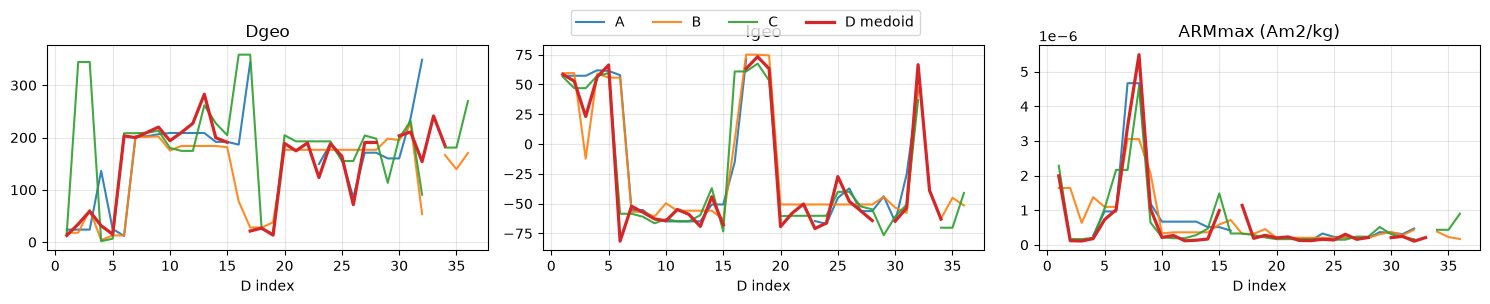

In [139]:
aligned_to_medoid = plot_all_sections_to_medoid(
    sections=sections,
    params=params,
    pair_alignments=pair_alignments_anchor,
    medoid=medoid_name_anchor,
    section_names=section_names,
    param_names=params,
    skips=skips,
    agg="mean",
    ncols=3,
    show_points=False,
)

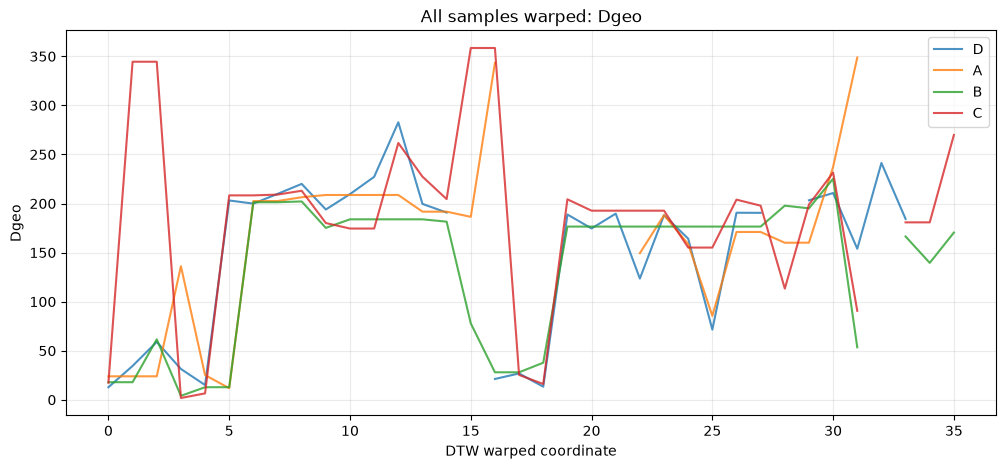

In [140]:
plot_all_warped_param(
    aligned_to_medoid=aligned_to_medoid,
    params=params,
    param_name="Dgeo"
)

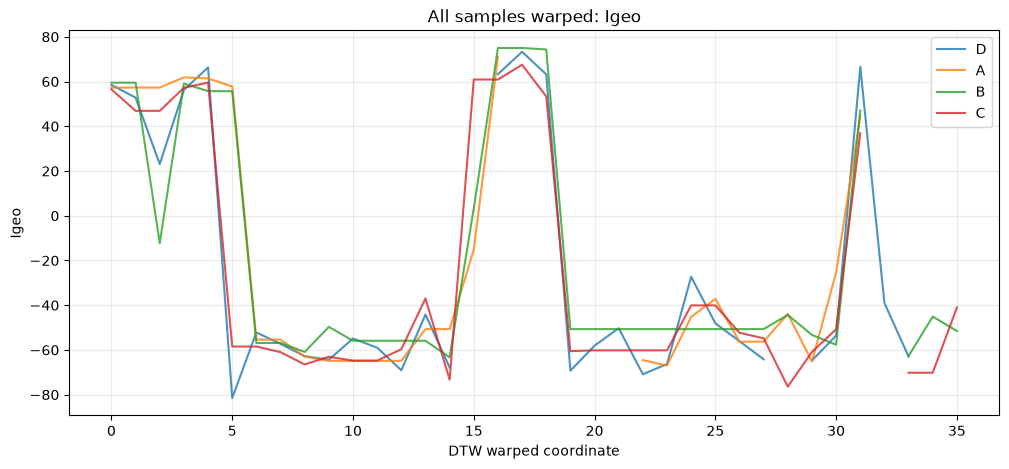

In [141]:
plot_all_warped_param(
    aligned_to_medoid=aligned_to_medoid,
    params=params,
    param_name="Igeo"
)

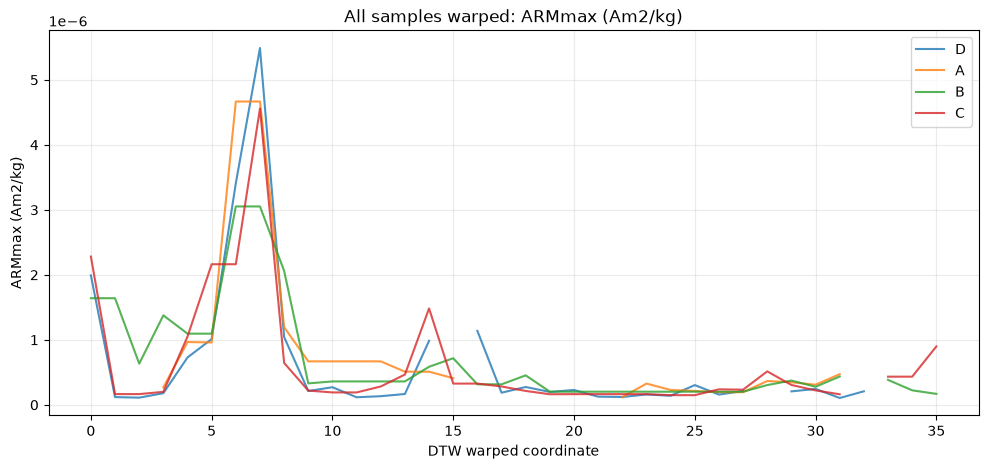

In [142]:
plot_all_warped_param(
    aligned_to_medoid=aligned_to_medoid,
    params=params,
    param_name="ARMmax (Am2/kg)"
)

In [147]:
param_name = "Dgeo"
param_id = params.index(param_name)

other = "B"   

medoid_warped = warped_to_medoid[other]["medoid_values"][:, param_id]
other_warped  = warped_to_medoid[other]["other_values"][:, param_id]

In [145]:
medoid_warped

array([ 12.8,  34.5,  59. ,  31.4,  15. , 203.1, 199.9, 209.8, 220. ,
       193.9, 193.9, 193.9, 209.6, 227.2, 282.8, 199.6, 190.8,   nan,
         nan,   nan,  21.2,  26.8,  13.3,  13.3, 188.8, 174.6, 189.7,
       123.5, 188.1, 164.2,  71.5, 190.6, 190.5,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan, 203.3,
       210.7, 153.9, 153.9, 241.3, 184.3, 184.3,   nan,   nan, 199.5])

In [146]:
other_warped

array([ 17.9,  17.9,  61.6,   4. ,  12.8,  12.8, 201.3, 201.3, 202.1,
       182.8, 186.1, 156.6, 183.9, 183.9, 183.9, 183.9, 181.5, 127.7,
         nan,  28. ,  28. ,  28. ,  28. ,  47.5, 176.5, 176.5, 176.5,
       176.5, 176.5, 176.5, 176.5, 176.5, 176.5, 336.3, 191.7, 176.9,
       238.1, 229.4, 200.1, 133.5, 213.4, 251.9, 147.3,  57.3, 195.1,
       225.3,  56.8,  50.1,   nan, 145. , 187.8, 139.5,   nan, 170.4])